# Winter Olympics 2026 - Analysis

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# Load cleaned datasets
df = pd.read_csv("../data/processed/cleaned_sports_data.csv")

# Create country-level dataframe (one row per country)
country_df = df.drop_duplicates(subset="Country")

print(df.shape)
country_df.head()

(113, 15)


,Country,Gold,Silver,Bronze,Total,population,gdp_per_capita_usd,temperature,Sport,Sport_Gold,Sport_Silver,Sport_Bronze,Sport_Total,sport_dominance_pct,climate_zone
0,Norway,18,12,11,41,5640194,87497.217965,4.1832,Alpine Skiing,0,1,1,2,4.88,Cold
7,United States of America,12,12,9,33,345410175,81032.262118,12.2240,Alpine Skiing,2,1,1,4,12.12,Mild
18,Netherlands,10,7,3,20,18290019,63515.603078,11.1760,Short Track Speed Skating,5,1,1,7,35.00,Mild
20,Italy,10,6,14,30,58941446,39277.083878,13.1340,Alpine Skiing,2,1,2,5,16.67,Mild
30,Germany,8,10,8,26,83570702,54776.766824,10.4072,Alpine Skiing,0,2,0,2,7.69,Mild


In [28]:
#df_total_medals.head()

## RQ1: To what extent do population size, GDP and average annual temperature predict the total medal count at the 2026 Winter Olympics? 

We use multiple linear regression to examine the relationship between a country’s total medal count and selected macro-level characteristics: population size, GDP per capita, and average annual temperature. Linear regression is a statistical method that models how a dependent variable (here, total medals) changes in response to one or more independent variables. By estimating coefficients for each predictor, the model allows us to assess both the direction and strength of these relationships, as well as their overall explanatory power.

In [29]:
# Predictors (independent variables)
X = country_df[['population', 'gdp_per_capita_usd', 'temperature']]

# Target (dependent variable)
y = country_df['Total']
    
# Create model  - used for predictions
model = LinearRegression()

# Fit model
model.fit(X, y)

# Coefficients
# print("Intercept:", model.intercept_)
# print("Coefficients:", model.coef_)


# Add constant (intercept) - needed in this option
X_adv = sm.add_constant(X)

# Fit model - used for better statistics
model_adv = sm.OLS(y, X_adv).fit()

# Summary
print(model_adv.summary())

                            OLS Regression Results                            
Dep. Variable:                  Total   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.357
Method:                 Least Squares   F-statistic:                     6.186
Date:                Sat, 04 Apr 2026   Prob (F-statistic):            0.00272
Time:                        14:40:01   Log-Likelihood:                -103.81
No. Observations:                  29   AIC:                             215.6
Df Residuals:                      25   BIC:                             221.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.2351      6

### Interpretation of Results

The regression model explains a moderate share of the variation in total medal counts, with an $R^2$ of 0.426 and an adjusted $R^2$ of 0.357. This indicates that approximately 35–43% of the differences in medal outcomes across countries can be explained by population size, GDP per capita, and average annual temperature. The overall model is statistically significant ($p = 0.0027$), suggesting that these variables jointly provide meaningful explanatory power.

Examining individual predictors, GDP per capita has a positive and statistically significant effect ($p = 0.001$), indicating that wealthier countries tend to win more medals. Population size also shows a positive relationship and is marginally significant ($p = 0.065$), suggesting that larger countries may have an advantage, although this effect is weaker and less certain. In contrast, average annual temperature does not have a statistically significant effect ($p = 0.552$), implying that climate is not an important predictor in this model.

It is important to note that the condition number is very large, which may indicate multicollinearity or scaling issues among the predictors. This could reduce the reliability of the estimated coefficients and should be taken into account when interpreting the results.

Overall, the results suggest that economic capacity (GDP per capita) is the strongest predictor of Olympic medal success in this model, with population playing a secondary role and temperature showing no meaningful impact.

However, this model has limited generalizability, as it is based solely on data from the 2026 Winter Olympics and includes only countries that won at least one medal.

## RQ2: Which countries perform significantly above or below their predicted medal count?

To address RQ2, we compare each country’s actual medal count with the value predicted by the regression model. The difference between these values (residuals) indicates whether a country performed above or below expectations. Positive differences represent overperformance, while negative differences indicate underperformance.

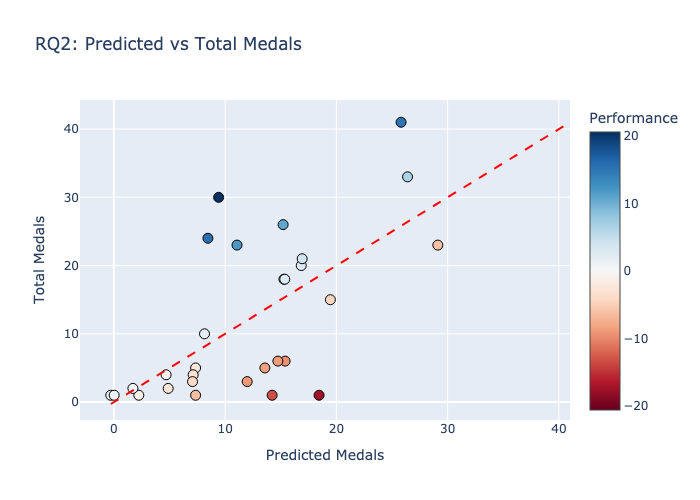

In [ ]:
# Predictions
predictions = model.predict(X)

country_df = country_df.copy()
country_df['Predictions'] = predictions
country_df['abs_diff'] = country_df['Total'] - country_df['Predictions']
country_df['rel_diff'] = (country_df['Total'] - country_df['Predictions']) / country_df['Predictions']

fig0 = go.Figure()

fig0.add_trace(
    go.Scatter(
        x=country_df["Predictions"],
        y=country_df["Total"],
        mode="markers",
        text=country_df["Country"],
        
        marker=dict(
            size=10,
            color=country_df["abs_diff"],   
            colorscale="RdBu",                      
            cmid=0,                                 
            colorbar=dict(title="Performance"),
            line=dict(color="black", width=1)
        ),
        
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Prediction: %{x}<br>"
            "Actual: %{y}<br>"
            "Performance: %{marker.color:.2f}<extra></extra>"
        )
    )
)

# Add x = y line
min_val = min(country_df["Predictions"].min(), country_df["Total"].min())
max_val = max(country_df["Predictions"].max(), country_df["Total"].max())

fig0.add_trace(
    go.Scatter(
        x=[min_val, max_val],
        y=[min_val, max_val],
        mode="lines",
        name="Perfect prediction (x = y)",
        line=dict(dash="dash", color="red")
    )
)

fig0.update_layout(showlegend=False)
fig0.update_xaxes(title_text="Predicted Medals")
fig0.update_yaxes(title_text="Total Medals")
fig0.update_layout(height=500, title_text="RQ2: Predicted vs Total Medals")
fig0.show() #interactive

fig0.show(renderer="png") #static

The scatter plot visualizes this relationship: countries above the diagonal line ($x = y$) won more medals than predicted (overperformers), while those below the line underperformed relative to expectations.

The color intensity represents the magnitude of over- or underperformance, with stronger colors indicating a larger deviation from the predicted medal count (either above or below expectations).

In [31]:
# Top 3 overperformers
best_3 = country_df.sort_values(by="abs_diff", ascending=False).head(3)

# Top 3 underperformers
worst_3 = country_df.sort_values(by="abs_diff", ascending=True).head(3)

print("Top 3 overperformers:")
print(best_3[["Country", "Total", "Predictions", "abs_diff"]])

print("\nTop 3 underperformers:")
print(worst_3[["Country", "Total", "Predictions", "abs_diff"]])

# Top 3 overperformers - relative
best_3 = country_df.sort_values(by="rel_diff", ascending=False).head(3)

# Top 3 underperformers - relative
worst_3 = country_df.sort_values(by="rel_diff", ascending=True).head(3)

print("\nTop 3 overperformers - relatively:")
print(best_3[["Country", "Total", "Predictions", "rel_diff"]])

print("\nTop 3 underperformers - relatively:")
print(worst_3[["Country", "Total", "Predictions", "rel_diff"]])

Top 3 overperformers:
   Country  Total  Predictions   abs_diff
20   Italy     30     9.415314  20.584686
66   Japan     24     8.451573  15.548427
0   Norway     41    25.815598  15.184402

Top 3 underperformers:
       Country  Total  Predictions   abs_diff
107    Denmark      1    18.444032 -17.444032
112    Belgium      1    14.225497 -13.225497
84   Australia      6    15.393697  -9.393697

Top 3 overperformers - relatively:
     Country  Total  Predictions   rel_diff
109  Georgia      1     0.026274  37.060042
20     Italy     30     9.415314   2.186298
66     Japan     24     8.451573   1.839708

Top 3 underperformers - relatively:
     Country  Total  Predictions  rel_diff
95    Brazil      1    -0.282317 -4.542114
107  Denmark      1    18.444032 -0.945782
112  Belgium      1    14.225497 -0.929704


### Findings

In absolute terms, the strongest overperformers are Italy, Japan, and Norway. These countries achieved substantially higher medal counts than predicted by the model, suggesting that factors not captured by population, GDP, and temperature—such as sports specialization, investment in winter sports, or historical strength—play an important role. On the other hand, Denmark, Belgium, and Australia are the largest underperformers, with actual medal counts falling well below model predictions.

When considering relative differences (scaled by predicted values), smaller countries become more prominent. Georgia stands out as the strongest relative overperformer, far exceeding its very low predicted medal count. Italy and Japan also remain among the top relative overperformers. In contrast, Brazil appears as the largest relative underperformer, although this result is influenced by a very small (and even negative) predicted value, which makes the relative measure unstable. Denmark and Belgium again appear among the strongest underperformers.

Overall, this analysis highlights that while the regression model captures general trends, it does not fully explain country-specific performance. Some nations consistently outperform expectations, likely due to unobserved factors such as sports infrastructure, athlete development programs, or cultural emphasis on winter sports.

## RQ3: Do countries with larger populations tend to win more medals?

### Scatter Plot: Population vs Total Medals
To visualize the relationship between population size and total medal count, we use a scatter plot with a logarithmic x-axis, since population values span several orders of magnitude (from ~1M to ~1.4B).

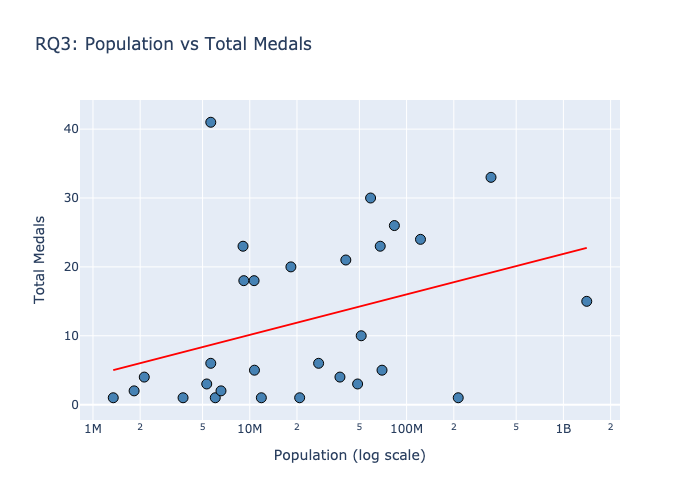

In [ ]:
# Calculate regression line on log scale for population
log_pop = np.log10(country_df["population"])
m, b = np.polyfit(log_pop, country_df["Total"], 1)
x_range = np.logspace(log_pop.min(), log_pop.max(), 100)
y_range = m * np.log10(x_range) + b

fig = go.Figure()

# Scatter plot: population vs total medals
fig.add_trace(
    go.Scatter(
        x=country_df["population"],
        y=country_df["Total"],
        mode="markers",
        text=country_df["Country"],
        marker=dict(size=10, color="steelblue", line=dict(color="black", width=1)),
        hovertemplate="<b>%{text}</b><br>Population: %{x:,}<br>Total Medals: %{y}<extra></extra>"
    )
)

# Add regression line
fig.add_trace(
    go.Scatter(
        x=x_range,
        y=y_range,
        mode="lines",
        line=dict(color="red"),
        name="Regression line",
        showlegend=False
    )
)

fig.update_xaxes(title_text="Population (log scale)", type="log")
fig.update_yaxes(title_text="Total Medals")
fig.update_layout(height=500, title_text="RQ3: Population vs Total Medals", showlegend=False)
fig.show() #interactive

fig.show(renderer="png") #static

The scatter plot with a logarithmic x-axis shows a moderate positive trend between population size and total medal count. However, the data points are widely scattered around the regression line, indicating high variability. For example, Norway (population ~5.6M) achieves 41 medals while China (population ~1.4B) wins only 15. Since the data is non-normally distributed, Spearman correlation could be more appropriate than Pearson for this analysis.

### Correlation Analysis
Before testing the relationship between population and total medals, we first double-check whether both variables are normally distributed using the Shapiro-Wilk test. Based on the results, we select the appropriate correlation method.

In [33]:
# Shapiro-Wilk normality test
stat1, p1 = stats.shapiro(country_df["population"])
stat2, p2 = stats.shapiro(country_df["Total"])
print(f"Shapiro-Wilk (population): stat={stat1:.3f}, p={p1:.3f}")
print(f"Shapiro-Wilk (Total medals): stat={stat2:.3f}, p={p2:.3f}")
print("Both variables are non-normally distributed, Spearman correlation is more appropriate.\n")

# Spearman correlation
corr_sp, p_sp = stats.spearmanr(country_df["population"], country_df["Total"])
print("Correlation Analysis")
print(f"Population vs Total Medals: r={corr_sp:.3f}, p={p_sp:.3f}")

Shapiro-Wilk (population): stat=0.353, p=0.000
Shapiro-Wilk (Total medals): stat=0.853, p=0.001
Both variables are non-normally distributed, Spearman correlation is more appropriate.

Correlation Analysis
Population vs Total Medals: r=0.423, p=0.022


### Findings
The Spearman correlation coefficient (r = 0.423, p = 0.022) indicates a moderate positive relationship between population size and total medal count, which is statistically significant. However, the scatter plot shows high variability around the regression line, suggesting that while larger populations tend to win more medals, population size alone is not a sufficient predictor of Winter Olympic success.

## RQ4: Is there a statistically significant relationship between average annual temperature and total medal success?

First, let's check which countries belong to which category.

In [34]:
# Check which countries belong to which climate zone
print(country_df[["Country", "temperature", "Total", "climate_zone"]].sort_values("Total", ascending=False).to_string(index=False))

                   Country  temperature  Total climate_zone
                    Norway       4.1832     41         Cold
  United States of America      12.2240     33         Mild
                     Italy      13.1340     30         Mild
                   Germany      10.4072     26         Mild
                     Japan      13.7060     24         Mild
                    France      13.7100     23         Mild
               Switzerland       7.3770     23         Cold
                    Canada       0.5432     21         Cold
               Netherlands      11.1760     20         Mild
                    Sweden       6.3934     18         Cold
                   Austria       8.0310     18         Mild
People's Republic of China      13.2360     15         Mild
         Republic of Korea      13.3520     10         Mild
                   Finland       5.6714      6         Cold
                 Australia      19.3880      6         Warm
             Great Britain      10.2528 

### Scatter Plot: Temperature vs Total Medals
To explore the relationship between climate and medal performance, we visualize average annual temperature against total medal count. Countries are color-coded by climate zone (Cold, Mild, Warm) to reveal potential group differences.

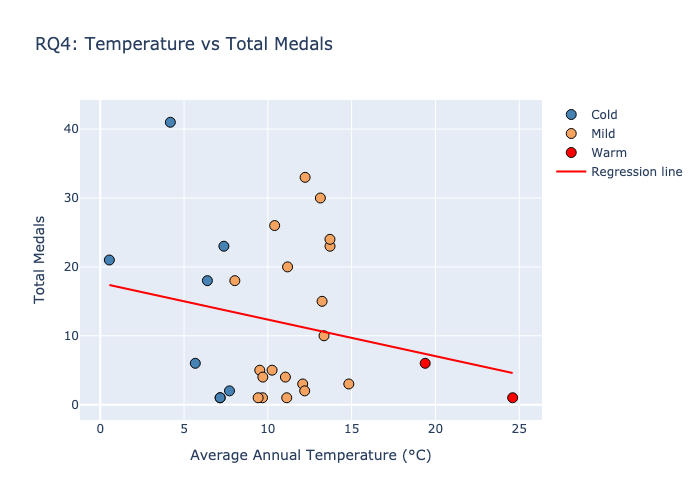

In [ ]:
# Define color map for climate zones
color_map = {"Cold": "steelblue", "Mild": "sandybrown", "Warm": "red"}

# Calculate regression line
m, b = np.polyfit(country_df["temperature"], country_df["Total"], 1)
x_range = np.linspace(country_df["temperature"].min(), country_df["temperature"].max(), 100)
y_range = m * x_range + b

fig1 = go.Figure()

# Scatter plot: temperature vs total medals, colored by climate zone
for zone, group in country_df.groupby("climate_zone"):
    fig1.add_trace(
        go.Scatter(
            x=group["temperature"],
            y=group["Total"],
            mode="markers",
            name=zone,
            text=group["Country"],
            marker=dict(size=10, color=color_map[str(zone)], line=dict(color="black", width=1)),
            hovertemplate="<b>%{text}</b><br>Temperature: %{x:.1f}°C<br>Total Medals: %{y}<extra></extra>"
        )
    )

# Add regression line
fig1.add_trace(
    go.Scatter(
        x=x_range,
        y=y_range,
        mode="lines",
        line=dict(color="red", dash="solid"),
        name="Regression line"
    )
)

fig1.update_xaxes(title_text="Average Annual Temperature (°C)")
fig1.update_yaxes(title_text="Total Medals")
fig1.update_layout(height=500, title_text="RQ4: Temperature vs Total Medals")
fig1.show() #interactive

fig1.show(renderer="png") #static


The scatter plot reveals a weak negative trend between temperature and total medal count. cold countries (blue) cluster in the upper left, while warm countries (red) appear in the lower right with fewer medals. However, several mild countries (orange) such as USA, Italy and France also achieve high medal counts, indicating that temperature is not the sole determinant of success. Since the data points are widely scattered around the regression line, we further investigate whether the relationship is statistically significant by first testing for normality.

### Box Plot: Medal Distribution by Climate Zone

To compare medal distributions across climate groups more clearly, we use a box plot showing the spread and median of total medals for each climate zone.

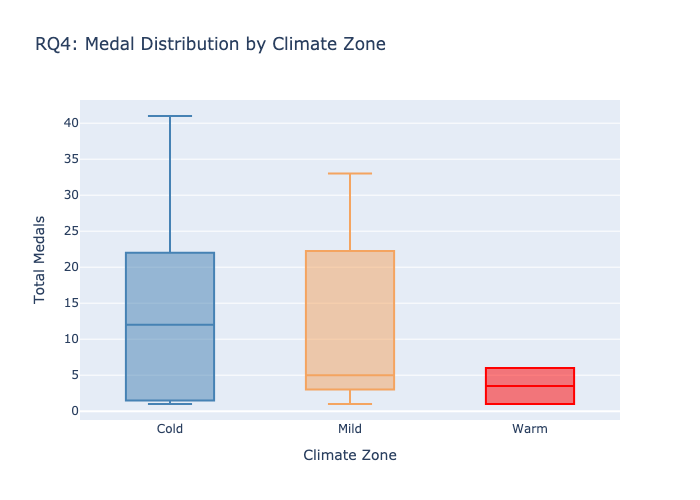

In [ ]:

# Box plot: medal distribution by climate zone
fig2 = px.box(
    country_df,
    x="climate_zone",
    y="Total",
    color="climate_zone",
    color_discrete_map={"Cold": "steelblue", "Mild": "sandybrown", "Warm": "red"},
    title="RQ4: Medal Distribution by Climate Zone",
    labels={"climate_zone": "Climate Zone", "Total": "Total Medals"},
    category_orders={"climate_zone": ["Cold", "Mild", "Warm"]}
)
fig2.update_layout(height=500, showlegend=False)
fig2.show() #interactive

fig2.show(renderer="png") #static

The box plot confirms that cold countries have the highest median medal count (~12) and the widest range, reaching up to 41 medals. Mild countries show high variability, reflecting the presence of both strong performers like USA and Italy and weaker ones. Warm countries consistently perform at lower levels with a narrow distribution. These patterns suggest a general climate advantage for colder nations, though exceptions exist.

### Correlation Analysis
Before testing the relationship between temperature and total medal count, we first check whether both variables are normally distributed using the Shapiro-Wilk test. Based on the results, we select the appropriate correlation method.

In [37]:
# Check normality using Shapiro-Wilk test
stat1, p1 = stats.shapiro(country_df["temperature"])
stat2, p2 = stats.shapiro(country_df["Total"])
print(f"Shapiro-Wilk (temperature): stat={stat1:.3f}, p={p1:.3f}")
print(f"Shapiro-Wilk (Total medals): stat={stat2:.3f}, p={p2:.3f}")

# Spearman correlation
corr_sp, p_sp = stats.spearmanr(country_df["temperature"], country_df["Total"])
print(f"Spearman: r={corr_sp:.3f}, p={p_sp:.3f}")

Shapiro-Wilk (temperature): stat=0.939, p=0.096
Shapiro-Wilk (Total medals): stat=0.853, p=0.001
Spearman: r=0.028, p=0.886


Since total medal count is non-normally distributed (Shapiro-Wilk p < 0.05), Spearman correlation is more appropriate than Pearson. We used it to test whether the observed negative trend between temperature and total medal count is statistically significant.

### Findings
The Spearman correlation coefficient (r = 0.028, p = 0.886) indicates virtually no relationship between average annual temperature and total medal count. This is not statistically significant, confirming that temperature alone is not a reliable predictor of Winter Olympic success. However, the box plot suggests that cold countries tend to perform better as a group, indicating that climate may play an indirect role when combined with other factors.

## RQ5: Do certain countries show a pattern of specialization in specific Winter Olympic sports, and does this concentration relate to their overall medal success?

To answer this question, we first examine the overall medal distribution across countries, then analyze which sports each country dominates using a heatmap. Finally, we calculate a specialization index to quantify how concentrated each country's medals are in a single sport, and test whether this concentration correlates with overall medal success.

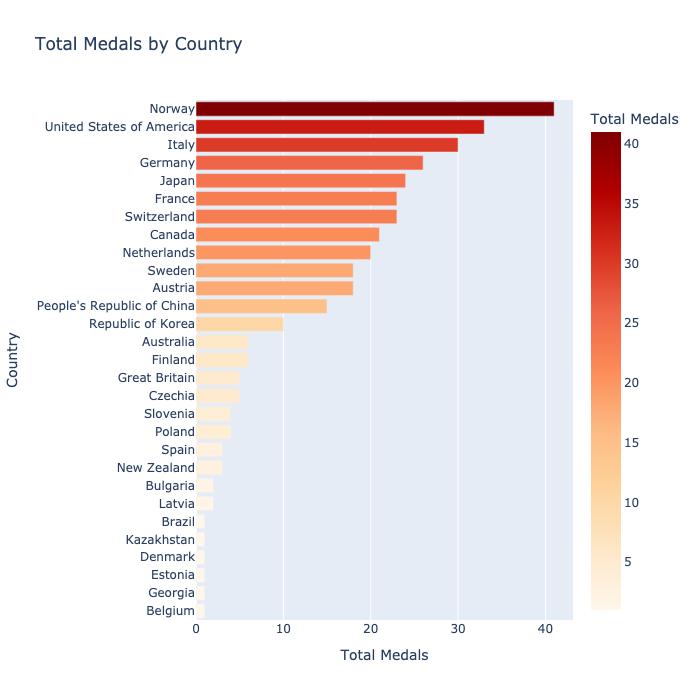

In [ ]:
# Sort countries by total medals for overview
top_countries = country_df.sort_values("Total", ascending=True)

# Horizontal bar chart: total medals by country
fig = px.bar(
    top_countries,
    x="Total",
    y="Country",
    orientation="h",
    title="Total Medals by Country",
    labels={"Total": "Total Medals", "Country": "Country"},
    color="Total",
    color_continuous_scale="OrRd"
)
fig.update_layout(height=700)
fig.show() #interactive

fig.show(renderer="png") #static

Norway leads the 2026 Winter Olympics with 41 medals, followed by the United States (33) and Italy (30). The top 5 countries account for a disproportionately large share of total medals, while the majority of participating countries win 5 or fewer. This suggests a strong concentration of Winter Olympic success among a small group of nations, which motivates a deeper analysis of sport-level specialization patterns.

The heatmap below shows how many medals each country won in each sport. Darker colors indicate higher medal counts, revealing patterns of specialization.

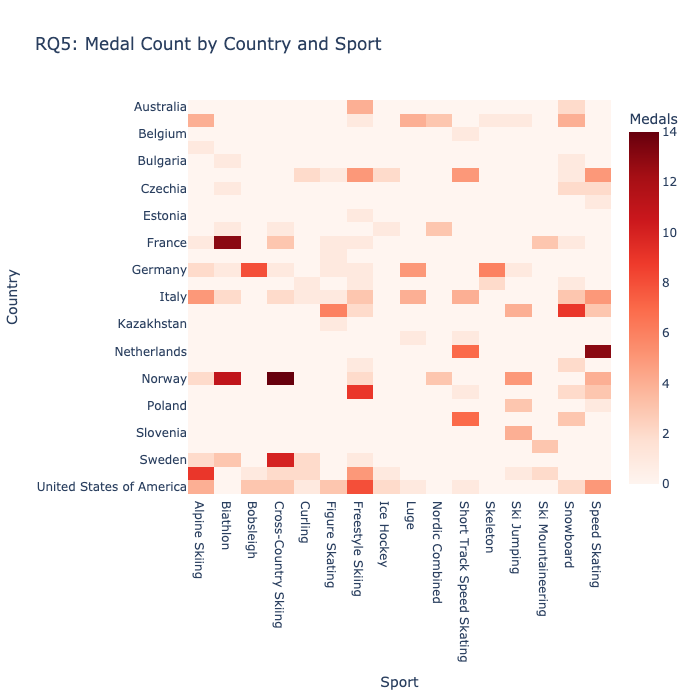

In [ ]:
# Pivot table: countries vs sports
pivot = df.pivot_table(index="Country", columns="Sport", values="Sport_Total", fill_value=0)

# Heatmap: medal count by country and sport
fig = px.imshow(
    pivot,
    title="RQ5: Medal Count by Country and Sport",
    labels={"x": "Sport", "y": "Country", "color": "Medals"},
    color_continuous_scale="Reds",
    aspect="auto"
)
fig.update_layout(height=700)
fig.show() #interactive

fig.show(renderer="png") #static

The heatmap clearly shows that several countries dominate specific sports. For example, Norway excels in Cross-Country Skiing, the Netherlands in Speed Skating, and France in Biathlon. This suggests strong specialization patterns among top-performing countries.

### Specialization Index
To quantify specialization, we calculate the ratio of a country's highest medal count in a single sport to its total medal count. A value of 1.0 means all medals came from one sport, while lower values indicate medals are spread across multiple sports.

In [40]:
# Calculate specialization index: max sport medals / total medals
spec_df = country_df.copy().reset_index(drop=True)

# Get max medal count in a single sport per country
max_sport = df.groupby("Country")["Sport_Total"].max().reset_index()
max_sport.columns = ["Country", "max_sport"]

# Get dominant sport (sport with most medals) per country
dominant = df.loc[df.groupby("Country")["Sport_Total"].idxmax()][["Country", "Sport"]].reset_index(drop=True)
dominant.columns = ["Country", "dominant_sport"]

# Merge and calculate index
spec_df = spec_df.merge(max_sport, on="Country").merge(dominant, on="Country")
spec_df["spec_index"] = (spec_df["max_sport"] / spec_df["Total"]).round(2)

print(spec_df[["Country", "Total", "max_sport", "spec_index", "dominant_sport"]].sort_values("spec_index", ascending=False).to_string(index=False))

                   Country  Total  max_sport  spec_index            dominant_sport
                   Belgium      1          1        1.00 Short Track Speed Skating
                   Estonia      1          1        1.00          Freestyle Skiing
                     Spain      3          3        1.00        Ski Mountaineering
                  Slovenia      4          4        1.00               Ski Jumping
                Kazakhstan      1          1        1.00            Figure Skating
                   Denmark      1          1        1.00             Speed Skating
                    Brazil      1          1        1.00             Alpine Skiing
                   Georgia      1          1        1.00            Figure Skating
                    Poland      4          3        0.75               Ski Jumping
         Republic of Korea     10          7        0.70 Short Track Speed Skating
                 Australia      6          4        0.67          Freestyle Skiing
    

### Does specialization relate to overall success?
Now we test whether countries that specialize more in specific sports tend to win more or fewer medals overall. Before testing the relationship between the specialization index and total medal count, we first check whether both variables are normally distributed using the Shapiro-Wilk test to determine the appropriate correlation method.

In [41]:
# Check normality using Shapiro-Wilk test
stat1, p1 = stats.shapiro(spec_df["spec_index"])
stat2, p2 = stats.shapiro(spec_df["Total"])
print(f"Shapiro-Wilk (spec_index): stat={stat1:.3f}, p={p1:.3f}")
print(f"Shapiro-Wilk (Total medals): stat={stat2:.3f}, p={p2:.3f}")

corr_sp, p_sp = stats.spearmanr(spec_df["spec_index"], spec_df["Total"])

print(f"Spearman: r={corr_sp:.3f}, p={p_sp:.3f}")

Shapiro-Wilk (spec_index): stat=0.895, p=0.007
Shapiro-Wilk (Total medals): stat=0.853, p=0.001
Spearman: r=-0.806, p=0.000


Both variables are non-normally distributed (Shapiro-Wilk p < 0.05), so Spearman correlation is more appropriate than Pearson. The Spearman result is strong: r = -0.806, p = 0.000, indicating a very strong and statistically significant negative relationship between specialization index and total medal count.

### Scatter Plot: Specialization Index vs Total Medals
To visualize the relationship between specialization and overall medal success, we plot the specialization index against total medal count. Each point represents a country, colored by its dominant sport.

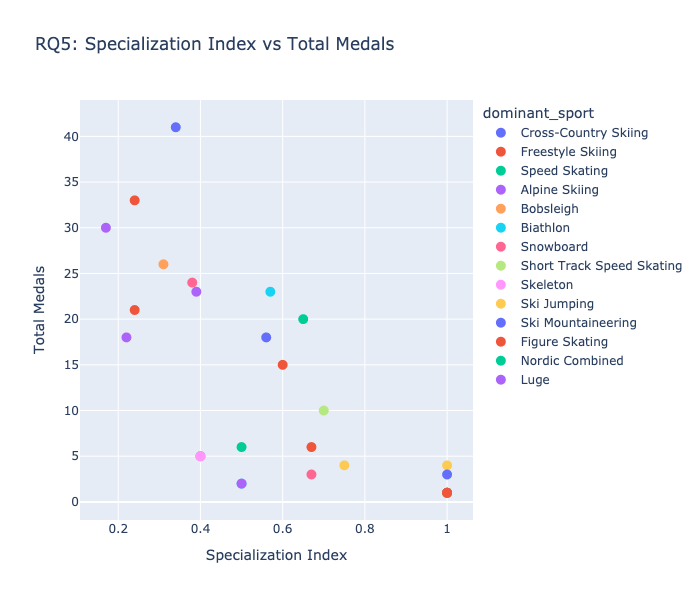

In [ ]:
# Scatter plot: specialization index vs total medals, colored by dominant sport
fig = px.scatter(
    spec_df,
    x="spec_index",
    y="Total",
    color="dominant_sport",
    hover_name="Country",
    title="RQ5: Specialization Index vs Total Medals",
    labels={"spec_index": "Specialization Index", "Total": "Total Medals"}
)
fig.update_traces(marker=dict(size=10))
fig.update_layout(height=600)
fig.show() #interactive

fig.show(renderer="png") #static

The scatter plot confirms the strong negative relationship between the specialization index and total medal count. Countries with a low specialization index (left side) such as Italy, US and Norway achieve the highest medal counts, while countries with a high specialization index (right side) such as Belgium, Estonia and Brazil win only 1-4 medals. This pattern is consistent with the Spearman correlation of r = -0.806.

### Findings
The Spearman correlation coefficient (r = -0.806, p = 0.000) indicates a very strong and statistically significant negative relationship between specialization and total medal count. Countries that spread their medals across multiple sports tend to achieve significantly higher overall medal counts, while countries that concentrate on a single sport tend to win fewer medals overall. This suggests that versatility across winter sports disciplines is a key factor in overall Olympic success.